# Phase 5 — 카메라–LiDAR 융합 기준선 (실무 방식 재구성)

**목표**: YOLO 2D 박스(Phase 4) 안에 투영되는 LiDAR 점을 골라 물체의 **3D 중심**(Velodyne 좌표, m) 을 추정한다.
정답지(`notebooks/05_camera_lidar_fusion.ipynb` 5.x 절, `src/perceptrack3d/fusion/frustum_fusion.py::fuse_frame_raw`) 와 같은 결과를,
**검색해서 가져다 붙이는 방식**으로 다시 만든다. 프레임 174 를 예제로 쓴다 (정상·중복·배경 오염이 한 프레임에 다 있다).

## 이 노트북에서 가져오는 것

| 조각 | 출처 | 라이선스 | 왜 |
|---|---|---|---|
| 1. 2D 박스 안에 투영되는 LiDAR 점 고르기 | Frustum PointNets 공식 코드 `kitti/kitti_object.py::get_lidar_in_image_fov`, `kitti/prepare_data.py::extract_frustum_data` | Apache-2.0 | 2D 박스 → 프러스텀 점 추출을 KITTI 에서 이미 해 둔 코드 |
| 2. 2D 박스 축소(shrink) | 코드 없음. Frustum PointNets 논문(arXiv 1711.08488) Fig. 3 / §4.2 의 "background clutter" 지적을 근거로 직접 작성 | (논문 인용) | 박스 가장자리에 걸리는 도로·건물 점 줄이기 |
| 3. 대표 깊이 통계 (`method="nearest"`) | NumPy 문서 `numpy.percentile` | BSD-3 (문서) | 쌍봉 분포에서 전경(가까운 쪽) 을 대표로 |
| 4. 중심 = 밴드 안 점의 좌표별 중앙값 | NumPy 문서 `numpy.median` | BSD-3 (문서) | 소수 이상점에 강한 3D 중심 |
| 5. 표면 편향 관찰 (GT 와 BEV 비교) | KITTI raw devkit `readme.txt` "Tracklet Labels" | KITTI (연구용) | 우리 중심이 GT 중심보다 얼마나 가까운지 숫자로 |

규칙: 정답지 모듈(`perceptrack3d.fusion.*`) 은 **검증 셀(C)** 에서만 import 한다. Phase 1~4 의 모듈(로더·캘리브레이션·투영·검출 JSON) 과 GT 파서는 이 노트북의 학습 대상이 아니므로 준비 셀에서 쓴다.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

from perceptrack3d.config import load_config
from perceptrack3d.data.kitti_loader import KittiDataset                     # Phase 1
from perceptrack3d.geometry.calibration import KittiCalibration              # Phase 2 (P_velo_to_img 3x4 만 쓴다)
from perceptrack3d.geometry.projection import project_velo_to_image          # Phase 3 (검증 셀에서 기준으로만)
from perceptrack3d.detection.detector import load_detections_json            # Phase 4 결과(JSON) 읽기
from perceptrack3d.evaluation.tracklets import gt_boxes_by_frame, gt_in_front_fov   # GT (조각 5 비교용, 파서는 08 노트북 몫)

cfg = load_config()                                   # 경로는 여기서만 조합한다
ds = KittiDataset(cfg)
calib = KittiCalibration.from_dir(cfg["dataset"]["calib_dir"])
dets_all = load_detections_json(f"{cfg['outputs']['dir']}/phase4/detections.json")
gts_all = gt_boxes_by_frame(ds.tracklets_path)

FRAME = 174
fr = ds.load_frame(FRAME)
img, pts = fr["image"], fr["points"]                  # (H, W, 3) uint8 BGR, (N, 4) float32 [x, y, z, r] Velodyne
H, W = img.shape[:2]
dets = dets_all[FRAME]                                # Detection2D 리스트, xyxy 는 image_02 픽셀
gts = [b for b in gt_in_front_fov(gts_all[FRAME]) if b.center[0] <= cfg["fusion"]["roi"]["x_max"]]
print("image", img.shape, img.dtype, "| points", pts.shape, pts.dtype, "| detections", len(dets), "| GT (카메라 FOV 안, ≤70 m)", len(gts))
for k, d in enumerate(dets):
    print(f"  det{k}: {d.class_name:<4} conf={d.confidence:.2f} xyxy={np.round(d.xyxy).astype(int)}")

image (375, 1242, 3) uint8 | points (119911, 4) float32 | detections 7 | GT (카메라 FOV 안, ≤70 m) 10
  det0: car  conf=0.72 xyxy=[564 180 618 227]
  det1: car  conf=0.56 xyxy=[1014  197 1105  234]
  det2: car  conf=0.53 xyxy=[270 183 303 205]
  det3: car  conf=0.51 xyxy=[535 181 573 200]
  det4: car  conf=0.43 xyxy=[140 183 199 211]
  det5: car  conf=0.40 xyxy=[530 183 550 200]
  det6: car  conf=0.37 xyxy=[1115  194 1188  231]


### 조각 1. 2D 박스 안에 투영되는 LiDAR 점 고르기 (frustum 추출)

- **검색어**: `kitti 2d bounding box lidar points frustum python`
- **출처**: Frustum PointNets 공식 저장소 — `kitti/kitti_object.py::get_lidar_in_image_fov`, `kitti/prepare_data.py::extract_frustum_data`, `kitti/kitti_util.py::Calibration.project_rect_to_image` — https://github.com/charlesq34/frustum-pointnets — Apache-2.0 — 2026-09-08 — `notebooks_2nd/sources/frustum_pointnets/{kitti_object.py, prepare_data.py, kitti_util.py}`
- **왜 이걸 가져오나**: "2D 검출 박스 → 그 박스 안에 떨어지는 LiDAR 점" 이 Phase 5 의 뼈대다. Frustum PointNets 는 학습 데이터를 만들 때 KITTI 에서 정확히 이 일을 한다.
- **읽을 때 볼 곳**: `kitti_object.py` 138~149행 `get_lidar_in_image_fov` (이미지 안 점 마스크 + `clip_distance`), `prepare_data.py` 192~213행 (`pc_image_coord` 로 `box_fov_inds` 5줄을 만들고 `img_fov_inds` 와 AND), `kitti_util.py` 180~188행 (픽셀 = 동차좌표를 깊이로 나눔).

용어: **프러스텀(frustum)** = 카메라 중심에서 2D 박스 네 모서리로 뻗는 사각뿔. "점이 프러스텀 안에 있다" = "카메라 앞에 있고 투영하면 박스 안에 떨어진다".

In [2]:
# ORIGINAL: frustum-pointnets/kitti/kitti_object.py :: get_lidar_in_image_fov, Apache-2.0
def get_lidar_in_image_fov(pc_velo, calib, xmin, ymin, xmax, ymax,
                           return_more=False, clip_distance=2.0):
    ''' Filter lidar points, keep those in image FOV '''
    pts_2d = calib.project_velo_to_image(pc_velo)
    fov_inds = (pts_2d[:,0]<xmax) & (pts_2d[:,0]>=xmin) & \
        (pts_2d[:,1]<ymax) & (pts_2d[:,1]>=ymin)
    fov_inds = fov_inds & (pc_velo[:,0]>clip_distance)
    imgfov_pc_velo = pc_velo[fov_inds,:]
    if return_more:
        return imgfov_pc_velo, pts_2d, fov_inds
    else:
        return imgfov_pc_velo

# ORIGINAL: frustum-pointnets/kitti/kitti_util.py :: Calibration.project_rect_to_image (180~188행), Apache-2.0
#   (클래스 메서드라 그대로는 실행 불가 → 주석. 아래 B 셀의 어댑터가 이 계산을 그대로 따른다)
#     def project_rect_to_image(self, pts_3d_rect):
#         ''' Input: nx3 points in rect camera coord.
#             Output: nx2 points in image2 coord.
#         '''
#         pts_3d_rect = self.cart2hom(pts_3d_rect)
#         pts_2d = np.dot(pts_3d_rect, np.transpose(self.P)) # nx3
#         pts_2d[:,0] /= pts_2d[:,2]
#         pts_2d[:,1] /= pts_2d[:,2]
#         return pts_2d[:,0:2]

# ORIGINAL: frustum-pointnets/kitti/prepare_data.py :: extract_frustum_data (192~213행 발췌), Apache-2.0
#   (for 루프 안이라 그대로는 실행 불가 → 주석. B 셀에서 이 5줄을 그대로 옮겨 쓴다)
#         _, pc_image_coord, img_fov_inds = get_lidar_in_image_fov(pc_velo[:,0:3],
#             calib, 0, 0, img_width, img_height, True)
#         ...
#                 xmin,ymin,xmax,ymax = box2d
#                 box_fov_inds = (pc_image_coord[:,0]<xmax) & \
#                     (pc_image_coord[:,0]>=xmin) & \
#                     (pc_image_coord[:,1]<ymax) & \
#                     (pc_image_coord[:,1]>=ymin)
#                 box_fov_inds = box_fov_inds & img_fov_inds
#                 pc_in_box_fov = pc_rect[box_fov_inds,:]
print("원본 함수 정의 완료:", get_lidar_in_image_fov.__doc__.strip())

원본 함수 정의 완료: Filter lidar points, keep those in image FOV


In [3]:
# 원본 Calibration 은 KITTI *object* 벤치마크의 calib 텍스트(P2, R0_rect, Tr_velo_to_cam) 를 읽는다. 우리는 raw 데이터라 파일 형식이
# 달라서, Phase 2 의 KittiCalibration 이 이미 곱해 둔 P_velo_to_img (3x4 = P_rect_02 @ R_rect_00 @ T_velo_to_cam) 로
# 원본이 기대하는 메서드 이름(project_velo_to_image) 만 흉내 낸다. 계산은 원본 project_rect_to_image 와 같다.
class CalibAdapter:                                                        # CHANGED: raw 캘리브레이션 → 원본 인터페이스
    def project_velo_to_image(self, pts_3d_velo):
        pts_3d_hom = np.hstack((pts_3d_velo, np.ones((pts_3d_velo.shape[0], 1))))   # cart2hom
        pts_2d = np.dot(pts_3d_hom, np.transpose(calib.P_velo_to_img))     # nx3 = [u·d, v·d, d]
        pts_2d[:,0] /= pts_2d[:,2]
        pts_2d[:,1] /= pts_2d[:,2]
        return pts_2d[:,0:2]

pc_velo = pts[:, 0:3].astype(np.float64)                                   # (N, 3) Velodyne, reflectance 버림
imgfov_pc_velo, pc_image_coord, img_fov_inds = get_lidar_in_image_fov(pc_velo, CalibAdapter(), 0, 0, W, H, True)
print("pc_image_coord", pc_image_coord.shape, pc_image_coord.dtype, "| 이미지 안 점", img_fov_inds.sum(), "/", len(pc_velo))
print("픽셀 범위 u", pc_image_coord[img_fov_inds, 0].min().round(1), "~", pc_image_coord[img_fov_inds, 0].max().round(1),
      "| v", pc_image_coord[img_fov_inds, 1].min().round(1), "~", pc_image_coord[img_fov_inds, 1].max().round(1))

# clip_distance 가 하는 일: 원본은 깊이(d) 의 부호를 검사하지 않고 나눈다. 카메라 *뒤* 의 점은 d < 0 이라 u = (u·d)/d 가
# 멀쩡한 픽셀처럼 나온다 (거울상). Velodyne x > clip_distance 조건이 이 점들을 걸러 낸다. 인자를 무력화하면:
no_clip_inds = get_lidar_in_image_fov(pc_velo, CalibAdapter(), 0, 0, W, H, True, clip_distance=-1e9)[2]
print(f"clip_distance=2.0 → {img_fov_inds.sum()} 점, clip 없음 → {no_clip_inds.sum()} 점 (차이 {no_clip_inds.sum() - img_fov_inds.sum()} 개는 카메라 뒤 점의 거울상)")

# 검출 박스마다 box_fov_inds — 원문 5줄 그대로. 원본은 pc_rect(정류 카메라 좌표) 를 모으지만 우리는 Velodyne 을 유지한다.
box_full = []                                                              # 검출별 "전체 박스 안 점" 의 원본 인덱스
print(f"\n{'det':>3} {'class':<5} {'xyxy (px)':>22} {'박스 안 점':>8}  Velodyne x 범위 [m]")
for k, det in enumerate(dets):
    xmin,ymin,xmax,ymax = det.xyxy
    box_fov_inds = (pc_image_coord[:,0]<xmax) & \
        (pc_image_coord[:,0]>=xmin) & \
        (pc_image_coord[:,1]<ymax) & \
        (pc_image_coord[:,1]>=ymin)
    box_fov_inds = box_fov_inds & img_fov_inds
    pc_in_box_fov = pc_velo[box_fov_inds,:]                                # CHANGED: pc_rect → pc_velo (출력 좌표계를 Velodyne 으로 유지)
    box_full.append(np.flatnonzero(box_fov_inds))
    print(f"{k:>3} {det.class_name:<5} ({xmin:5.0f},{ymin:4.0f},{xmax:5.0f},{ymax:4.0f}) {len(pc_in_box_fov):>8}  {pc_in_box_fov[:,0].min():5.1f} ~ {pc_in_box_fov[:,0].max():5.1f}")

pc_image_coord (119911, 2) float64 | 이미지 안 점 18300 / 119911
픽셀 범위 u 0.1 ~ 1241.8 | v 128.4 ~ 375.0
clip_distance=2.0 → 18300 점, clip 없음 → 35432 점 (차이 17132 개는 카메라 뒤 점의 거울상)

det class              xyxy (px)   박스 안 점  Velodyne x 범위 [m]
  0 car   (  564, 180,  618, 227)      171   23.2 ~  79.2
  1 car   ( 1014, 197, 1105, 234)      200   24.0 ~  53.4
  2 car   (  270, 183,  303, 205)       35   16.6 ~  49.3
  3 car   (  535, 181,  573, 200)       29   23.5 ~  70.4
  4 car   (  140, 183,  199, 211)       29   23.7 ~  37.7
  5 car   (  530, 183,  550, 200)       15   47.9 ~  48.2
  6 car   ( 1115, 194, 1188, 231)      138   25.7 ~  51.7


In [4]:
# 검증: 정답지 project_velo_to_image (Phase 3) + uv_in_box (Phase 5) 와 같은 점 집합인가
from perceptrack3d.fusion.point_filters import uv_in_box                   # 정답지 (검증 전용)

uv, depth, mask = project_velo_to_image(pts, calib, (H, W))               # uv[i] ↔ pts[mask][i]
idx = np.flatnonzero(mask)
print("이미지 안 점: 원본 방식", img_fov_inds.sum(), "| 정답지 mask", mask.sum(), "| 같은 집합?", np.array_equal(img_fov_inds, mask))
print("픽셀 좌표 allclose (float32 vs float64):", np.allclose(pc_image_coord[img_fov_inds], uv, atol=1e-3))
for k, det in enumerate(dets):
    ref = np.zeros(len(pts), bool); ref[idx[uv_in_box(uv, det.xyxy)]] = True
    mine = np.zeros(len(pts), bool); mine[box_full[k]] = True
    print(f"det{k}: 원본 방식 {mine.sum():>4}  정답지 {ref.sum():>4}  일치 {np.array_equal(mine, ref)}")

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


이미지 안 점: 원본 방식 18300 | 정답지 mask 18300 | 같은 집합? True
픽셀 좌표 allclose (float32 vs float64): True
det0: 원본 방식  171  정답지  171  일치 True
det1: 원본 방식  200  정답지  200  일치 True
det2: 원본 방식   35  정답지   35  일치 True
det3: 원본 방식   29  정답지   29  일치 True
det4: 원본 방식   29  정답지   29  일치 True
det5: 원본 방식   15  정답지   15  일치 True
det6: 원본 방식  138  정답지  138  일치 True


**차이와 이유**
- 정답지는 `d > 0`(카메라 앞) 으로 뒤쪽 점을 걸러내고, 원본은 `Velodyne x > clip_distance(2 m)` 로 걸러낸다. 이 프레임에서는 두 집합이 같다 (0 < x ≤ 2 m 이면서 이미지에 들어오는 점이 없기 때문). **`clip_distance` 를 지우면 카메라 뒤 점 1만 7천 개가 거울상으로 섞여 들어온다** — 남의 코드를 붙일 때 "기본값이 있는 인자가 왜 있는지" 를 확인해야 하는 이유.
- 박스 경계: 원본은 반개구간(`>= xmin`, `< xmax`), 정답지는 폐구간(`<=`). 픽셀 좌표가 실수라 이 프레임에서는 차이가 없다. 정수로 반올림해 쓰면 달라질 수 있다.
- 원본은 박스 안 점을 **정류 카메라 좌표(pc_rect)** 로 모은다 (뒤에 오는 PointNet 이 그 좌표를 기대). 우리는 GT(tracklet) 와 바로 비교하려고 **Velodyne** 을 유지한다. "어느 좌표계의 점을 모으느냐" 가 출력 중심의 좌표계를 결정한다.

### 조각 2. 2D 박스 축소(shrink) — 직접 작성

- **검색어**: `frustum point cloud background clutter 2d box`
- **출처**: 코드 없음. 근거만 논문에서 — Qi et al., "Frustum PointNets for 3D Object Detection from RGB-D Data", CVPR 2018 — https://arxiv.org/abs/1711.08488 (arXiv v2) — Fig. 3 캡션, §4.2 첫 문단 — 2026-09-08 — 발췌 `notebooks_2nd/sources/frustum_pointnets/paper_1711.08488_excerpt.txt`
- **왜 이걸 가져오나**: 논문은 "2D 박스에서 뻗은 프러스텀 안에는 전경 가림체(foreground occluder) 와 배경 잡동사니(background clutter) 가 넓게 퍼져 있다" 고 지적하고, 학습된 3D segmentation 망으로 푼다. 우리는 학습 없이 가장 싼 완화책 — 박스를 각 변 10% 줄여 가장자리에 걸리는 도로·건물·나무 점을 덜 담기 — 을 직접 쓴다. 출처가 없는 "실무 관행" 이므로 `# 직접 작성` 으로 표시한다.
- **읽을 때 볼 곳**: 논문 Fig. 3 캡션 ("…a wide spread of points with both foreground occluder (bikes) and background clutter (building)"), §4.2 첫 문단 ("occluding objects and background clutter is common in natural scenes").

In [5]:
# ORIGINAL: arXiv 1711.08488 (Frustum PointNets) :: Fig. 3 caption / Sec. 4.2 — 코드가 아니라 문장이므로 주석으로 인용
#   "Right: bird's eye view of the LiDAR points in the extruded frustum from 2D box, where we see a wide spread of
#    points with both foreground occluder (bikes) and background clutter (building)."
#   "However, this problem is not easy as occluding objects and background clutter is common in natural scenes (as in Fig. 3),
#    which may severely distract the 3D localization task."

# 직접 작성: 박스를 각 변에서 비율 s 만큼 안쪽으로 줄인다 (s = 0.1 → 가로·세로 80% 크기의 가운데 박스)
def shrink(xyxy, s):
    x1, y1, x2, y2 = [float(v) for v in xyxy]
    w, h = x2 - x1, y2 - y1
    return np.array([x1 + s * w, y1 + s * h, x2 - s * w, y2 - s * h])

# 직접 작성: 조각 1 의 box_fov_inds 5줄을 함수로 (반개구간 규칙 그대로)
def in_box(pts_2d, xyxy):
    xmin, ymin, xmax, ymax = xyxy
    return (pts_2d[:,0]<xmax) & (pts_2d[:,0]>=xmin) & (pts_2d[:,1]<ymax) & (pts_2d[:,1]>=ymin)

print("예: (100, 50, 200, 150) 을 10% 축소 →", shrink((100, 50, 200, 150), 0.1))

예: (100, 50, 200, 150) 을 10% 축소 → [        110          60         190         140]


det class   박스 w×h px    전체 박스    축소 박스    줄어든 점
  0 car      54×47         171       97      43%
  1 car      91×36         200      112      44%
  2 car      33×22          35       30      14%
  3 car      38×20          29       20      31%
  4 car      59×29          29       25      14%
  5 car      20×17          15       13      13%
  6 car      72×37         138       83      40%


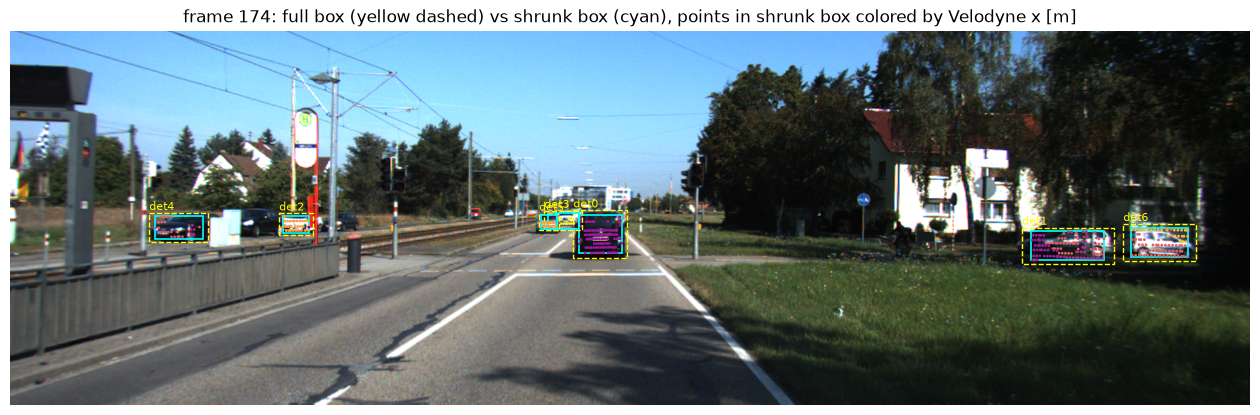

In [6]:
SHRINK = cfg["fusion"]["box_shrink"]                                       # 0.1
box_sel = []                                                               # 검출별 "축소 박스 안 점" 의 원본 인덱스 (뒤 조각에서 계속 씀)
print(f"{'det':>3} {'class':<5} {'박스 w×h px':>11} {'전체 박스':>8} {'축소 박스':>8} {'줄어든 점':>8}")
for k, det in enumerate(dets):
    sh = in_box(pc_image_coord, shrink(det.xyxy, SHRINK)) & img_fov_inds
    box_sel.append(np.flatnonzero(sh))
    w, h = det.xyxy[2] - det.xyxy[0], det.xyxy[3] - det.xyxy[1]
    print(f"{k:>3} {det.class_name:<5} {w:5.0f}×{h:<5.0f} {len(box_full[k]):>8} {sh.sum():>8} {1 - sh.sum() / len(box_full[k]):>8.0%}")

# 그림: 전체 박스(점선) 와 축소 박스(실선), 축소 박스 안 점을 Velodyne x(거리) 색으로
fig, ax = plt.subplots(figsize=(16, 5))
ax.imshow(img[:, :, ::-1])                                                 # OpenCV BGR → RGB
for k, det in enumerate(dets):
    x1, y1, x2, y2 = det.xyxy
    ax.add_patch(plt.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, ec="yellow", ls="--", lw=1))
    sx1, sy1, sx2, sy2 = shrink(det.xyxy, SHRINK)
    ax.add_patch(plt.Rectangle((sx1, sy1), sx2 - sx1, sy2 - sy1, fill=False, ec="cyan", lw=1.2))
    ax.text(x1, y1 - 3, f"det{k}", color="yellow", fontsize=8)
    q = box_sel[k]
    ax.scatter(pc_image_coord[q, 0], pc_image_coord[q, 1], s=4, c=pc_velo[q, 0], cmap="plasma", vmin=5, vmax=60, linewidths=0)
ax.set_xlim(0, W); ax.set_ylim(H, 0); ax.axis("off")
ax.set_title(f"frame {FRAME}: full box (yellow dashed) vs shrunk box (cyan), points in shrunk box colored by Velodyne x [m]")
plt.show()

In [7]:
# 검증: 정답지 shrink_box / uv_in_box 와 같은 박스·같은 점 집합인가
from perceptrack3d.fusion.point_filters import shrink_box                  # 정답지 (검증 전용)
for k, det in enumerate(dets):
    ref_box = shrink_box(det.xyxy, SHRINK)
    ref = idx[uv_in_box(uv, ref_box)]
    print(f"det{k}: 축소 박스 allclose {np.allclose(shrink(det.xyxy, SHRINK), ref_box)} | 점 집합 일치 "
          f"{np.array_equal(np.sort(box_sel[k]), np.sort(ref))} ({len(box_sel[k])} vs {len(ref)})")

det0: 축소 박스 allclose True | 점 집합 일치 True (97 vs 97)
det1: 축소 박스 allclose True | 점 집합 일치 True (112 vs 112)
det2: 축소 박스 allclose True | 점 집합 일치 True (30 vs 30)
det3: 축소 박스 allclose True | 점 집합 일치 True (20 vs 20)
det4: 축소 박스 allclose True | 점 집합 일치 True (25 vs 25)
det5: 축소 박스 allclose True | 점 집합 일치 True (13 vs 13)
det6: 축소 박스 allclose True | 점 집합 일치 True (83 vs 83)


### 조각 3. 대표 깊이 — 평균·중앙값·하위 백분위 (`numpy.percentile` 의 `method` 인자)

- **검색어**: `numpy percentile method nearest actual sample value`
- **출처**: NumPy 공식 문서 `numpy.percentile` — https://numpy.org/doc/stable/reference/generated/numpy.percentile.html — BSD-3-Clause (문서) — 2026-09-08 — 텍스트 발췌 `notebooks_2nd/sources/numpy_docs/percentile.txt`
- **왜 이걸 가져오나**: 박스 안 점의 깊이는 "물체(앞) + 배경(뒤)" 의 **쌍봉 분포**가 된다. 평균은 배경에 끌려가고, 중앙값도 배경이 절반을 넘으면 무너진다. "가까운 쪽 30%" 를 대표로 잡으려면 백분위가 필요하고, 그 값이 **실제 점의 값**이어야 다음 조각의 ±밴드가 비지 않는다 — 그래서 `method="nearest"` 다.
- **읽을 때 볼 곳**: Parameters 의 `method` 항목 — 기본 `'linear'` 는 두 표본 사이를 보간하고, `'lower'`/`'higher'`/`'nearest'` 는 실제 표본 값을 돌려주는 불연속(discontinuous) 방식이라는 설명. (1.22 이전 이름은 `interpolation`.)

용어: **깊이(depth)** = 투영 동차좌표의 3번째 성분 d = 정류 카메라 프레임의 z (광학축 방향 거리, m). Velodyne x 와 거의 같지만 약 0.27 m 오프셋과 미세한 회전 차이가 있다.

In [8]:
# ORIGINAL: numpy.percentile docs :: Examples, BSD-3-Clause
a = np.array([[10, 7, 4], [3, 2, 1]])
print(np.percentile(a, 50))            # 3.5
print(np.percentile(a, 50, axis=0))    # array([6.5, 4.5, 2.5])
print(np.percentile(a, 50, axis=1))    # array([7.,  2.])

# 직접 작성: 문서의 method 설명 확인 — 'linear'(기본) 는 표본 사이를 보간한 값, 'nearest' 는 실제 표본 값
d = np.array([10., 20., 30., 40., 50.])
print("p30 linear  =", np.percentile(d, 30), "  ← 표본에 없는 값 (10 과 20 사이를 보간)")
print("p30 nearest =", np.percentile(d, 30, method="nearest"), "  ← 표본 값")

3.5
[        6.5         4.5         2.5]
[          7           2]
p30 linear  = 22.0   ← 표본에 없는 값 (10 과 20 사이를 보간)
p30 nearest = 20.0   ← 표본 값


det    n    min p30 nearest p30 linear  median   mean    max
  0   97   23.0       23.11      23.11    23.1   23.3   24.0
  1  112   23.7       24.29      24.31    27.5   29.9   39.2
  2   30   16.4       47.03      47.02    47.2   46.4   49.1
  3   20   25.6       47.93      47.92    59.5   57.9   70.1
  4   25   25.8       34.07      34.08    34.2   33.4   37.5
  5   13   47.6       47.64      47.63    47.7   47.8   48.0
  6   83   37.1       37.24      37.24    37.3   41.6   51.2


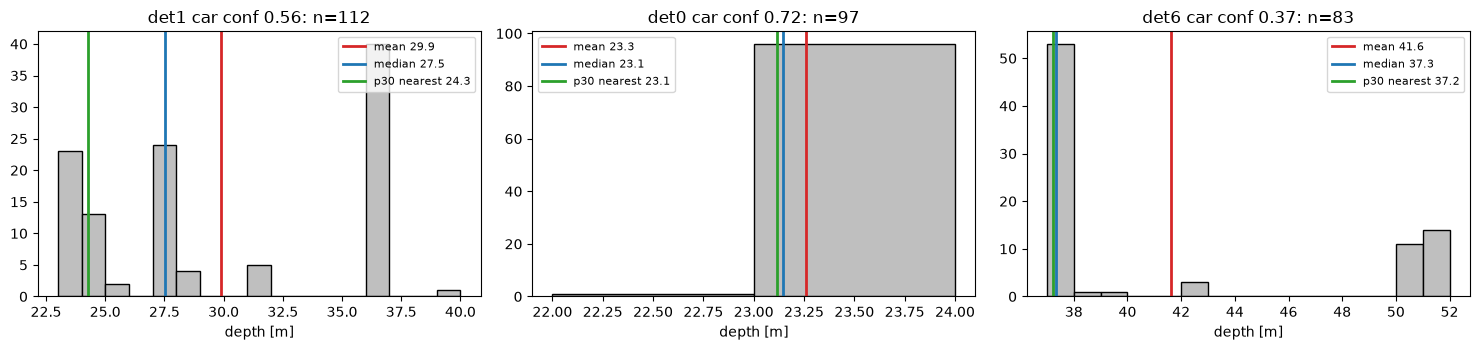

In [9]:
# 깊이 = 나누기 전 동차좌표의 3번째 성분 (조각 1 어댑터는 u, v 만 돌려주므로 여기서 한 줄로 다시 계산)
depth_all = (np.hstack((pc_velo, np.ones((len(pc_velo), 1)))) @ calib.P_velo_to_img.T)[:, 2]
PCT = cfg["fusion"]["depth_percentile"]                                    # 30
print(f"{'det':>3} {'n':>4} {'min':>6} {'p30 nearest':>11} {'p30 linear':>10} {'median':>7} {'mean':>6} {'max':>6}")
d_rep = []
for k in range(len(dets)):
    dd = depth_all[box_sel[k]]
    r = float(np.percentile(dd, PCT, method="nearest")); d_rep.append(r)
    print(f"{k:>3} {len(dd):>4} {dd.min():6.1f} {r:11.2f} {np.percentile(dd, PCT):10.2f} {np.median(dd):7.1f} {dd.mean():6.1f} {dd.max():6.1f}")

# 히스토그램: det1 (박스 안 점의 40% 가 30~45 m 뒤편 = 배경), det0 (깨끗한 앞차), det6
fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))
for ax, k in zip(axes, [1, 0, 6]):
    dd = depth_all[box_sel[k]]
    ax.hist(dd, bins=np.arange(np.floor(dd.min()), np.ceil(dd.max()) + 1, 1.0), color="0.75", edgecolor="k")
    for val, name, c in [(dd.mean(), "mean", "tab:red"), (np.median(dd), "median", "tab:blue"), (d_rep[k], f"p{PCT} nearest", "tab:green")]:
        ax.axvline(val, color=c, lw=2, label=f"{name} {val:.1f}")
    ax.set_title(f"det{k} {dets[k].class_name} conf {dets[k].confidence:.2f}: n={len(dd)}"); ax.set_xlabel("depth [m]"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

In [10]:
# 검증: (1) 우리 깊이 = 정답지 project_velo_to_image 의 depth, (2) 대표 깊이가 실제 표본 값인가 (밴드가 비지 않을 조건)
print("depth allclose (정답지 float32 vs 우리 float64):", np.allclose(depth_all[idx], depth, atol=1e-3))
for k in range(len(dets)):
    dd = depth_all[box_sel[k]]
    print(f"det{k}: d_rep={d_rep[k]:.3f} 가 표본에 있음 {bool(np.isclose(dd, d_rep[k]).any())} | linear 값 {np.percentile(dd, PCT):.3f} 는 표본에 있음 {bool(np.isclose(dd, np.percentile(dd, PCT)).any())}")
print("\n정답지 학습 노트(phase5_fusion.md 2절) 의 det1 수치: mean 29.9 / median 27.5 / p30 24.3 m — 위 표와 비교")

depth allclose (정답지 float32 vs 우리 float64): True
det0: d_rep=23.113 가 표본에 있음 True | linear 값 23.113 는 표본에 있음 True
det1: d_rep=24.288 가 표본에 있음 True | linear 값 24.311 는 표본에 있음 False
det2: d_rep=47.026 가 표본에 있음 True | linear 값 47.021 는 표본에 있음 False
det3: d_rep=47.925 가 표본에 있음 True | linear 값 47.921 는 표본에 있음 False
det4: d_rep=34.072 가 표본에 있음 True | linear 값 34.080 는 표본에 있음 False
det5: d_rep=47.639 가 표본에 있음 True | linear 값 47.632 는 표본에 있음 False
det6: d_rep=37.235 가 표본에 있음 True | linear 값 37.235 는 표본에 있음 True

정답지 학습 노트(phase5_fusion.md 2절) 의 det1 수치: mean 29.9 / median 27.5 / p30 24.3 m — 위 표와 비교


det1 을 보면 **mean(29.9) > median(27.5) > p30(24.3)** 순으로 배경의 영향이 줄어든다. 박스 안 112 점 중 약 40% 가 30~45 m 뒤편 점이라 중앙값조차 물체(24 m) 에서 3 m 넘게 벗어난다.
정답지 스윕(297 프레임, 2 m 매칭) 에서는 p10 → 569 매칭, **p30 → 621**, p50 → 655 였다. p50 이 살짝 낫지만 배경이 많은 박스에서 더 취약하므로 30 을 유지한다 (근본 해결은 Phase 6).

### 조각 4. 중심 = 대표 깊이 ± 밴드 안 점들의 좌표별 중앙값 (`numpy.median`)

- **검색어**: `numpy median axis 0 robust centroid`
- **출처**: NumPy 공식 문서 `numpy.median` — https://numpy.org/doc/stable/reference/generated/numpy.median.html — BSD-3-Clause (문서) — 2026-09-08 — `notebooks_2nd/sources/numpy_docs/median.txt`
- **왜 이걸 가져오나**: 대표 깊이 ± 1.5 m 안의 점만 남겨도 몇 개는 배경·노이즈일 수 있다. 평균 대신 **좌표별 중앙값**을 쓰면 소수의 이상점에 끌려가지 않는다. `axis=0` 이면 x, y, z 각각의 중앙값 → 3D 점 하나.
- **읽을 때 볼 곳**: `axis` 파라미터 ("Axis or axes along which the medians are computed"), Examples 의 `np.median(a, axis=0)`.

In [11]:
# ORIGINAL: numpy.median docs :: Examples, BSD-3-Clause
a = np.array([[10, 7, 4], [3, 2, 1]])
print(np.median(a))            # np.float64(3.5)
print(np.median(a, axis=0))    # array([6.5, 4.5, 2.5])
print(np.median(a, axis=1))    # array([7.,  2.])

3.5
[        6.5         4.5         2.5]
[          7           2]


det   축소 박스   밴드 안  center (x, y, z) [m, Velodyne]   mean 과의 차이 [m]
  0      97     97  ( 23.43,   0.67, -0.97)   0.12
  1     112     38  ( 24.21, -13.90, -1.51)   0.23
  2      30     28  ( 47.45,  21.19, -0.88)   0.20
  3      20      9  ( 48.19,   4.57, -0.81)   0.17
  4      25     13  ( 34.43,  21.26, -0.86)   0.18
  5      13     13  ( 48.03,   4.72, -1.05)   0.11
  6      83     53  ( 37.54, -27.81, -2.42)   0.10


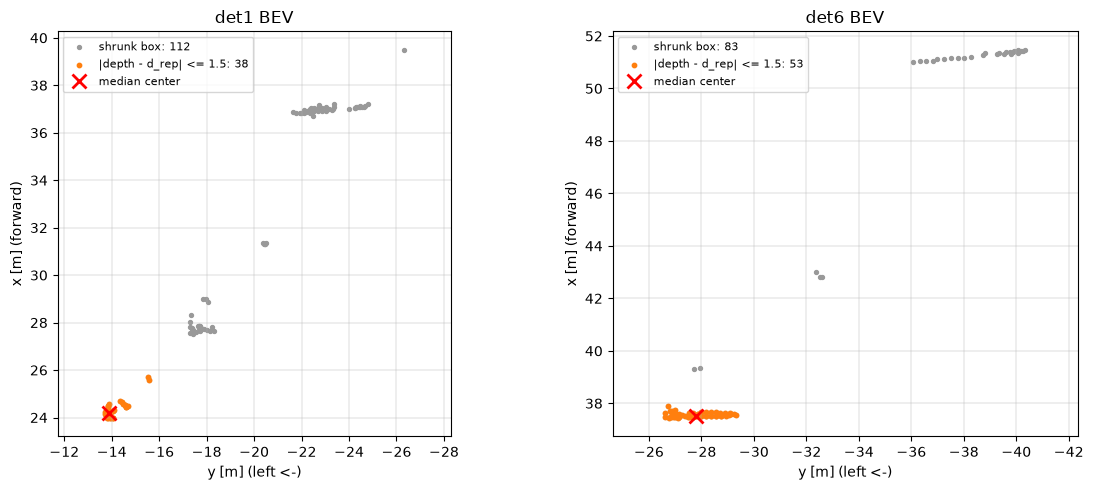

In [12]:
BAND = cfg["fusion"]["depth_band_m"]                                       # 1.5 m
centers = []                                                               # (center (3,), 사용한 점 인덱스)
print(f"{'det':>3} {'축소 박스':>7} {'밴드 안':>6}  center (x, y, z) [m, Velodyne]   mean 과의 차이 [m]")
for k in range(len(dets)):
    sel = box_sel[k]
    used = sel[np.abs(depth_all[sel] - d_rep[k]) <= BAND]                  # 대표 깊이 ± 1.5 m 안의 점
    c = np.median(pc_velo[used], axis=0)                                   # 좌표별 중앙값 → (3,)
    centers.append((c, used))
    print(f"{k:>3} {len(sel):>7} {len(used):>6}  ({c[0]:6.2f}, {c[1]:6.2f}, {c[2]:5.2f})   {np.linalg.norm(c - pc_velo[used].mean(axis=0)):.2f}")

# BEV: det1 의 축소 박스 안 점(회색) 과 밴드 안 점(색), 중심(빨간 ×). 밴드가 30~45 m 의 배경을 잘라 낸 것을 본다
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, k in zip(axes, [1, 6]):
    sel, (c, used) = box_sel[k], centers[k]
    ax.scatter(pc_velo[sel, 1], pc_velo[sel, 0], s=8, c="0.6", label=f"shrunk box: {len(sel)}")
    ax.scatter(pc_velo[used, 1], pc_velo[used, 0], s=10, c="tab:orange", label=f"|depth - d_rep| <= {BAND}: {len(used)}")
    ax.plot(c[1], c[0], "rx", ms=10, mew=2, label="median center")
    ax.set_xlim(pc_velo[sel, 1].max() + 2, pc_velo[sel, 1].min() - 2); ax.set_aspect("equal"); ax.grid(lw=0.3)
    ax.set_xlabel("y [m] (left <-)"); ax.set_ylabel("x [m] (forward)"); ax.set_title(f"det{k} BEV"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

In [13]:
# 검증: 정답지 fuse_frame_raw 의 center / n_points 와 비교 (status == "ok" 인 검출만; det5 는 정답지가 중복 제거로 invalid 처리 → 이어붙이기에서)
from perceptrack3d.fusion.frustum_fusion import fuse_frame_raw             # 정답지 (검증 전용)
ref_raw = fuse_frame_raw(pts, dets, calib, (H, W), cfg)
for k, o in enumerate(ref_raw):
    c, used = centers[k]
    if o.status != "ok":
        print(f"det{k}: 정답지 status={o.status} ({o.reason}) → 이어붙이기에서 비교"); continue
    print(f"det{k}: center allclose {np.allclose(c, o.center)} | n_points {len(used)} vs {o.n_points} | 점 집합 일치 {np.array_equal(np.sort(used), np.sort(o.point_indices))}")

det0: center allclose True | n_points 97 vs 97 | 점 집합 일치 True
det1: center allclose True | n_points 38 vs 38 | 점 집합 일치 True
det2: center allclose True | n_points 28 vs 28 | 점 집합 일치 True
det3: center allclose True | n_points 9 vs 9 | 점 집합 일치 True
det4: center allclose True | n_points 13 vs 13 | 점 집합 일치 True
det5: 정답지 status=invalid (duplicate_of_3) → 이어붙이기에서 비교
det6: center allclose True | n_points 53 vs 53 | 점 집합 일치 True


### 조각 5. 표면 편향 관찰 — GT(tracklet) 와 BEV 로 비교

- **검색어**: `kitti raw tracklet labels coordinate system velodyne`
- **출처**: KITTI raw development kit `readme.txt` "Tracklet Labels" 절 — https://www.cvlibs.net/datasets/kitti/raw_data.php (devkit_raw_data.zip) — KITTI (연구용) — 2026-09-08 — `notebooks_2nd/sources/kitti_devkit/devkit/readme.txt` 233~245행. XML 파서는 Phase 8 팀(08 노트북) 몫이라 여기서는 정답지 `gt_boxes_by_frame` 을 준비 셀에서 썼다.
- **왜 이걸 가져오나**: 우리 중심이 얼마나 맞는지 알려면 정답이 필요하다. readme 는 tracklet 이 **Velodyne 좌표**라고 못 박아 두었으므로, 우리 중심(Velodyne) 과 변환 없이 바로 뺄 수 있다.
- **읽을 때 볼 곳**: "All tracklets are represented in Velodyne coordinates." 한 줄, 그리고 3D 박스가 h, w, l + 프레임별 위치·BEV 회전으로 저장된다는 문단.

In [14]:
# ORIGINAL: kitti_devkit/devkit/readme.txt :: "Tracklet Labels" (241~245행), KITTI — 문서이므로 주석으로 인용
#   Each tracklet is stored as a 3D bounding box of given height, width and
#   length, spanning multiple frames. For each frame we have labeled 3D location
#   and rotation in bird's eye view. Additionally, occlusion / truncation
#   information is provided in the form of averaged Mechanical Turk label
#   outputs. All tracklets are represented in Velodyne coordinates.

# 직접 작성: BEV 박스 4 모서리 — 로컬 (±l/2, ±w/2) 를 yaw 만큼 돌려(Rz) 중심에 더한다. l 은 진행 방향(로컬 x), w 는 로컬 y.
def bev_corners(center, size, yaw):
    l, w = size[0], size[1]
    local = np.array([[l/2, w/2], [l/2, -w/2], [-l/2, -w/2], [-l/2, w/2]])
    c, s = np.cos(yaw), np.sin(yaw)
    return local @ np.array([[c, -s], [s, c]]).T + center[:2]

print("예: 중심 (10, 0), l=4, w=2, yaw=0 →", bev_corners(np.array([10., 0.]), np.array([4., 2.]), 0.0).tolist())

예: 중심 (10, 0), l=4, w=2, yaw=0 → [[12.0, 1.0], [12.0, -1.0], [8.0, -1.0], [8.0, 1.0]]


det  pred x    GT    GT x   BEV 거리     dx  GT l  GT w GT yaw°
  0   23.43 gt31    25.45     2.03  -2.02  4.50  1.63      -0
  1   24.21 gt34    28.49     5.20  -4.28  1.57  0.34       4   ← 3 m 안에 GT 없음 (라벨 없는 주차 차량 또는 오검출)
  2   47.45 gt14    49.22     1.82  -1.78  3.88  1.67     179
  3   48.19 gt12    49.25     1.07  -1.06  3.11  1.43    -180
  4   34.43 gt32    36.29     1.86  -1.86  4.15  1.31     175
  5   48.03 gt12    49.25     1.22  -1.22  3.11  1.43    -180
  6   37.54 gt35    38.09     0.59  -0.56  2.99  1.80     -86

GT 와 3 m 안에서 짝지어진 6 건의 dx 평균: -1.42 m  (음수 = GT 중심보다 센서 쪽에 있음)


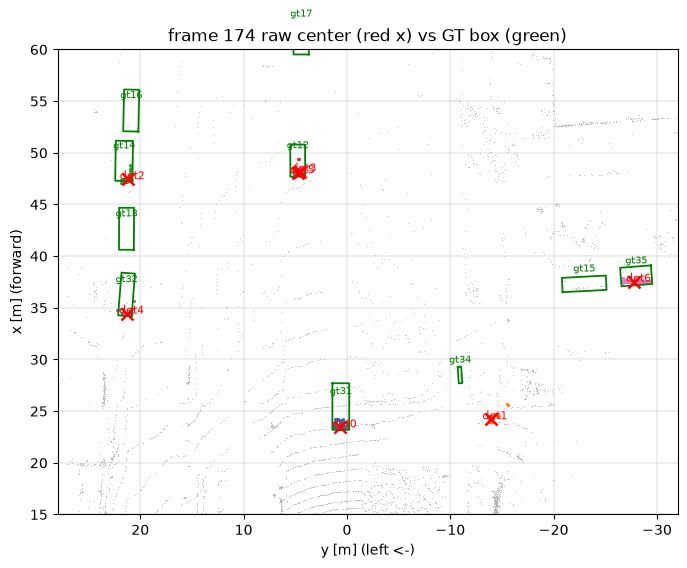

In [15]:
# 각 중심에서 BEV 로 가장 가까운 GT 를 찾고, 깊이 편차 dx = pred_x - gt_x 를 본다
print(f"{'det':>3} {'pred x':>7} {'GT':>5} {'GT x':>7} {'BEV 거리':>8} {'dx':>6} {'GT l':>5} {'GT w':>5} {'GT yaw°':>7}")
match = []                                                                 # (det k, BEV 거리, dx)
for k, (c, used) in enumerate(centers):
    d = np.array([np.linalg.norm(c[:2] - b.center[:2]) for b in gts]); j = int(d.argmin()); b = gts[j]
    dx = c[0] - b.center[0]
    note = ""
    if d[j] <= 3.0: match.append((k, d[j], dx))
    else: note = "   ← 3 m 안에 GT 없음 (라벨 없는 주차 차량 또는 오검출)"
    print(f"{k:>3} {c[0]:7.2f} gt{b.tracklet_id:<3} {b.center[0]:7.2f} {d[j]:8.2f} {dx:+6.2f} {b.size[0]:5.2f} {b.size[1]:5.2f} {np.degrees(b.yaw):7.0f}{note}")
dx_list = [dx for _, _, dx in match]
print(f"\nGT 와 3 m 안에서 짝지어진 {len(dx_list)} 건의 dx 평균: {np.mean(dx_list):+.2f} m  (음수 = GT 중심보다 센서 쪽에 있음)")

# BEV 그림: 점(회색), GT 박스(초록), 우리 중심(빨간 ×)
sub = pc_velo[np.random.default_rng(0).choice(len(pc_velo), 50000, replace=False)]
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(sub[:, 1], sub[:, 0], s=0.3, c="0.7", linewidths=0)
for b in gts:
    cc = bev_corners(b.center, b.size, b.yaw); cc = np.vstack([cc, cc[:1]])
    ax.plot(cc[:, 1], cc[:, 0], "g-", lw=1.3); ax.text(b.center[1], b.center[0] + 1.2, f"gt{b.tracklet_id}", color="g", fontsize=7, ha="center")
for k, (c, used) in enumerate(centers):
    ax.scatter(pc_velo[used, 1], pc_velo[used, 0], s=5, linewidths=0)
    ax.plot(c[1], c[0], "rx", ms=8, mew=1.8); ax.text(c[1] + 0.8, c[0], f"det{k}", color="r", fontsize=8)
ax.plot(0, 0, "b^", ms=9)
ax.set_xlim(28, -32); ax.set_ylim(15, 60); ax.set_aspect("equal"); ax.grid(lw=0.3)
ax.set_xlabel("y [m] (left <-)"); ax.set_ylabel("x [m] (forward)"); ax.set_title(f"frame {FRAME} raw center (red x) vs GT box (green)")
plt.show()

In [16]:
# 검증: 정답지 평가 코드(scripts/compare_fusion.py::evaluate_objects, 2 m 헝가리안 매칭) 의 깊이 bias 와 비교
import sys
sys.path.insert(0, f"{cfg['outputs']['dir']}/../scripts")
from compare_fusion import evaluate_objects                                # 정답지 (검증 전용)
r = evaluate_objects({FRAME: ref_raw}, gts_all, cfg, 2.0)
print(f"정답지 evaluate_objects (2 m 매칭): matched {r['n_matched']} / GT {r['n_gt']}, BEV 오차 mean {r['center']['mean_bev']:.2f} m, 깊이 bias {r['depth']['bias']:+.2f} m")
print(f"우리 (3 m 최근접 매칭): matched {len(dx_list)}, dx 평균 {np.mean(dx_list):+.2f} m")
same_rule = [dx for k, dist, dx in match if dist <= 2.0 and ref_raw[k].status == "ok"]   # 정답지 규칙: 2 m 안 + ok 인 것만
print(f"→ 정답지는 2 m 임계값이라 det0 (BEV 오차 2.03 m) 이 빠지고, 중복 처리된 det5 도 세지 않는다. 같은 규칙으로 고르면 "
      f"{len(same_rule)} 건, dx 평균 {np.mean(same_rule):+.2f} m 로 같다.")

정답지 evaluate_objects (2 m 매칭): matched 4 / GT 10, BEV 오차 mean 1.33 m, 깊이 bias -1.31 m
우리 (3 m 최근접 매칭): matched 6, dx 평균 -1.42 m
→ 정답지는 2 m 임계값이라 det0 (BEV 오차 2.03 m) 이 빠지고, 중복 처리된 det5 도 세지 않는다. 같은 규칙으로 고르면 4 건, dx 평균 -1.31 m 로 같다.


**표면 편향 (surface bias)** — LiDAR 는 물체의 **보이는 면**만 찍는다. 앞차라면 뒷면, 옆으로 선 차라면 옆면이다. 그 점들의 중앙값은 그 면 위에 있으므로 GT 중심(박스 기하 중심) 보다 센서 쪽으로 치우친다.
- det0 (gt31, yaw 0° = 정면 앞차, l = 4.5): dx ≈ −2.0 m ≈ −l/2. 뒷면이 보인다.
- det6 (gt35, yaw −85° = 옆으로 선 차, w = 1.8): dx ≈ −0.6 m ≈ −w/2. 옆면이 보인다.
즉 편차 ≈ "센서를 향한 치수의 절반" 이다. 통계 방법(평균/중앙값/백분위) 을 바꿔도 없어지지 않는다 — **점이 거기 없기 때문**이다. 정답지 전 프레임 평균 −1.29 m, 06 노트북의 표면→중심 오프셋이 이를 다룬다.

### 이어붙이기 — `fuse_frame_raw_mine`

조각 1(투영·박스 안 점) → 2(축소) → 3(대표 깊이) → 4(밴드·중앙값) 을 함수 하나로 잇고, 정답지가 하는 두 가지를 직접 보탠다:
- **status**: 축소 박스 안 점 0 → `empty`, `min_points`(5) 미만 → `sparse`, 그 외 `ok`.
- **중복 제거**: 서로 다른 박스의 중심이 BEV 에서 `dedup_distance_m`(1 m) 안이면 confidence 낮은 쪽을 `invalid`(duplicate). YOLO 가 같은 차에 박스 2개를 내는 경우(det3/det5) 를 하나로.

In [17]:
def fuse_frame_raw_mine(points, dets, calib, image_shape, cfg):
    '''조각 1~4 를 이어 붙인 Phase 5 기준선. 반환: 검출과 같은 순서의 dict 리스트.
    dict 키: status ("ok"|"empty"|"sparse"|"invalid"), reason, center (3,) Velodyne m 또는 None, n_points, point_indices'''
    f = cfg["fusion"]; H, W = image_shape
    pc = points[:, :3].astype(np.float64)
    proj = np.hstack((pc, np.ones((len(pc), 1)))) @ calib.P_velo_to_img.T          # (N, 3) = [u·d, v·d, d]   (조각 1)
    depth = proj[:, 2]
    with np.errstate(divide="ignore", invalid="ignore"):
        pts_2d = proj[:, :2] / depth[:, None]
    in_img = in_box(pts_2d, (0, 0, W, H)) & (pc[:, 0] > 2.0)                        # 이미지 안 + clip_distance
    out = []
    for det in dets:
        sel = np.flatnonzero(in_box(pts_2d, shrink(det.xyxy, f["box_shrink"])) & in_img)   # (조각 2)
        o = {"class_name": det.class_name, "confidence": float(det.confidence), "status": "ok", "reason": "",
             "center": None, "n_points": len(sel), "point_indices": sel}
        if len(sel) == 0:
            o["status"], o["reason"] = "empty", "no_points_in_box"
        elif len(sel) < f["min_points"]:
            o["status"], o["reason"] = "sparse", f"{len(sel)}<{f['min_points']}_points"
        else:
            d_rep = np.percentile(depth[sel], f["depth_percentile"], method="nearest")      # (조각 3)
            used = sel[np.abs(depth[sel] - d_rep) <= f["depth_band_m"]]
            o["center"], o["n_points"], o["point_indices"] = np.median(pc[used], axis=0), len(used), used   # (조각 4)
        out.append(o)
    # 중복 제거 (직접 작성): confidence 내림차순으로 돌며, 이미 남긴 중심과 BEV 1 m 안이면 탈락
    kept = []
    for i in sorted([i for i, o in enumerate(out) if o["status"] == "ok"], key=lambda i: -out[i]["confidence"]):
        j = next((j for j in kept if np.linalg.norm(out[i]["center"][:2] - out[j]["center"][:2]) < f["dedup_distance_m"]), None)
        if j is None:
            kept.append(i)
        else:
            out[i].update(status="invalid", reason=f"duplicate_of_{j}", center=None)
    return out

mine = fuse_frame_raw_mine(pts, dets, calib, (H, W), cfg)
print(f"{'det':>3} {'class':<5} {'status':<8} {'reason':<16} {'n_pts':>5}  center (x, y, z) [m]")
for k, o in enumerate(mine):
    c = "-" if o["center"] is None else "(" + ", ".join(f"{v:6.2f}" for v in o["center"]) + ")"
    print(f"{k:>3} {o['class_name']:<5} {o['status']:<8} {o['reason']:<16} {o['n_points']:>5}  {c}")

det class status   reason           n_pts  center (x, y, z) [m]
  0 car   ok                           97  ( 23.43,   0.67,  -0.97)
  1 car   ok                           38  ( 24.21, -13.90,  -1.51)
  2 car   ok                           28  ( 47.45,  21.19,  -0.88)
  3 car   ok                            9  ( 48.19,   4.57,  -0.81)
  4 car   ok                           13  ( 34.43,  21.26,  -0.86)
  5 car   invalid  duplicate_of_3      13  -
  6 car   ok                           53  ( 37.54, -27.81,  -2.42)


In [18]:
# 최종 검증: 정답지 fuse_frame_raw 와 프레임 174 전체 검출에서 status·reason·center·n_points 비교, 그리고 전체 297 프레임
def same(o, ref):
    if o["status"] != ref.status or o["reason"] != ref.reason or o["n_points"] != ref.n_points:
        return False
    if (o["center"] is None) != (ref.center is None):
        return False
    return o["center"] is None or np.allclose(o["center"], ref.center)

for k, (o, ref) in enumerate(zip(mine, ref_raw)):
    print(f"det{k}: {o['status']:<8} vs {ref.status:<8} | 일치 {same(o, ref)}")

n_det = n_bad = 0
for fid in ds.frame_ids():
    if fid not in dets_all or not dets_all[fid]:
        continue
    f2 = ds.load_frame(fid)
    a = fuse_frame_raw_mine(f2["points"], dets_all[fid], calib, f2["image"].shape[:2], cfg)
    b = fuse_frame_raw(f2["points"], dets_all[fid], calib, f2["image"].shape[:2], cfg)
    n_det += len(a); n_bad += sum(not same(x, y) for x, y in zip(a, b))
print(f"\n전체 시퀀스: 검출 {n_det} 건 중 정답지와 다른 것 {n_bad} 건")

det0: ok       vs ok       | 일치 True
det1: ok       vs ok       | 일치 True
det2: ok       vs ok       | 일치 True
det3: ok       vs ok       | 일치 True
det4: ok       vs ok       | 일치 True
det5: invalid  vs invalid  | 일치 True
det6: ok       vs ok       | 일치 True



전체 시퀀스: 검출 1325 건 중 정답지와 다른 것 0 건


### 여기서 배우는 것

- **기본값 있는 인자가 하는 일을 확인하라**: 원본 `get_lidar_in_image_fov` 는 깊이 부호를 검사하지 않는다. `clip_distance` 가 없으면 카메라 뒤 점 1만 7천 개가 거울상 픽셀로 섞여 들어온다.
- **어느 좌표계의 점을 모으느냐가 출력 좌표계다**: 원본은 정류 카메라 좌표(`pc_rect`) 를 모으고 우리는 Velodyne 을 유지했다. 중앙값은 좌표계마다 따로 내므로, 나중에 변환하면 값이 미묘하게 달라진다.
- **경계 규칙(반개구간 vs 폐구간) 과 dtype(float32 uv)**: 실수 픽셀에서는 같았지만 정수화하면 달라질 수 있다. 검증 셀이 "이 프레임에서 같다" 를 확인해 줬을 뿐, 항상 같다는 증명은 아니다.
- **`np.percentile` 기본 method 는 보간**: 표본에 없는 값이 나와 ±밴드가 빌 수 있다 (`[10, 20, 30, …]` 에서 p30 = 22 → 밴드 안 점 0). `method="nearest"` 로 실제 점 값을 쓴다.
- **통계를 바꿔도 표면 편향은 안 없어진다**: 점이 보이는 면에만 있다. 편차 ≈ 센서를 향한 치수의 절반. 이건 Phase 6 (06 노트북) 의 몫이다.

### 자가 점검 3문제

1. `get_lidar_in_image_fov` 의 `clip_distance` 인자를 무력화하면(`-1e9`) 이미지 안 점 수가 약 두 배가 된다. 어떤 점들이 왜 들어오나?
2. `np.percentile(d, 30)` (기본 method) 으로 대표 깊이를 잡고 ±1.5 m 밴드를 씌우면 어떤 경우에 밴드 안 점이 0 개가 될 수 있나?
3. det0 (정면 앞차) 의 dx ≈ −2.0 m 와 det6 (옆으로 선 차) 의 dx ≈ −0.6 m 는 무엇으로 설명되나? 백분위를 50 으로 바꾸면 이 편차가 사라지나?

<details><summary>답</summary>

1. 카메라 **뒤**의 점. 원본은 동차좌표를 깊이 d 로 나눌 때 d 의 부호를 검사하지 않아서, d < 0 인 점도 (u·d)/d 가 멀쩡한 픽셀 값이 된다 (거울상). `Velodyne x > 2 m` 조건이 이를 걸러 낸다. 정답지는 대신 `d > 0` 을 검사한다.
2. 보간된 백분위 값이 실제 점 사이에 떨어지고, 가장 가까운 점이 1.5 m 보다 멀 때. 예: 깊이가 [10, 20, 30, 40, 50] 이면 p30 = 22 → 22 ± 1.5 안에 점이 없다. 멀리 있어 링 간격이 성긴 물체에서 실제로 생기던 버그다.
3. 표면 편향. LiDAR 는 센서를 향한 면만 찍으므로 중앙값은 그 면 위에 있다. 정면 앞차는 뒷면(편차 ≈ l/2 ≈ 2 m), 옆으로 선 차는 옆면(편차 ≈ w/2 ≈ 0.9 m). 백분위를 바꿔도 점이 물체 내부에 없으므로 사라지지 않는다 — 클래스별 크기 prior 로 미는 06 노트북의 표면→중심 오프셋이 필요하다.
</details>